# Partículas — boletín III

### Perspectiva experimental: el trigger, leer un resultado y la estadística bayesiana

José A. Hernando

*Departamento de Física de Partículas. Universidade de Santiago de Compostela*

Curso 2026/27

In [1]:
# Configuración e imports
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats, integrate, optimize
from scipy.interpolate import PchipInterpolator

# Paleta Okabe-Ito (apta para daltónicos)
C_SIG, C_BKG, C_AUX = '#0072B2', '#E69F00', '#009E73'
DATOS = 'datos/'

## Contenido

Este notebook recoge las partes **computacionales** del boletín III, con la misma numeración que el boletín:

* **Ejercicio 6** — Diseño de un trigger de muones con datos simulados ($B_s^0 \to \mu^+ + \mu^-$ frente a $J/\psi$ *prompt*).
* **Ejercicio 8** — Leer un perfil de verosimilitud: $\mathcal{B}(B_s^0 \to \mu^+ + \mu^-)$ en CMS.
* **Ejercicio 10** — Leer una *posterior*: la masa del neutrino en KATRIN.

Los demás ejercicios, y el apartado (a) del 6, están resueltos en el boletín en pdf.

<div class="admonition tip">
<p class="admonition-title"><b>[>] Ejercicio 6 — Diseño de un trigger de muones</b></p>

Diseñas el trigger de muones de un experimento hacia delante como LHCb para buscar $B_s^0 \to \mu^+ + \mu^-$.
El primer nivel decide con **un solo muón**, con su momento $p$, su momento transverso $p_T$ y su parámetro de
impacto IP (la distancia mínima de la traza al vértice primario). Supón que todo el fondo del trigger son muones
de $J/\psi \to \mu^+ + \mu^-$ producidos en el vértice primario (*prompt*).

En `datos/trigger_bs2mumu.csv` y `datos/trigger_jpsi_prompt.csv` hay $5000$ sucesos simulados de cada tipo, con
los dos muones dentro de la aceptancia; columnas `p1, pt1, ip1, p2, pt2, ip2` ($p$ y $p_T$ en GeV, IP en $\mu$m).

Datos: $\mathcal{L} = 2\cdot10^{33}$ cm$^{-2}$s$^{-1}$; $\sigma(pp \to J/\psi + X) = 15\ \mu$b en $2<\eta<5$,
$\mathcal{B}(J/\psi \to \mu^+ + \mu^-) = 5.96\,\%$ y una fracción $0.45$ con los dos muones en la aceptancia;
$\sigma(pp \to b + \bar b + X) = 144\ \mu$b en $2<\eta<5$, $f_s = 0.10$, $\mathcal{B}(B_s^0 \to \mu^+ + \mu^-) =
3.6\cdot10^{-9}$ y una aceptancia de $0.50$; $\mathcal{L}_{int} = 5$ fb$^{-1}$ por año.

(b) Tasa de sucesos $J/\psi \to \mu^+ + \mu^-$ en la aceptancia: ¿cuántas veces supera los $20$ Hz asignados?
(c) Distribuciones de $p_T$ e IP: ¿qué variable separa mejor y por qué?
(d) El suceso pasa si **al menos un** muón cumple $p_T > p_T^{min}$ e IP $>$ IP$^{min}$. Elige los cortes para
$R \le 20$ Hz y da la eficiencia de la señal; compara cortes solo en $p_T$, solo en IP y en los dos. ¿Coincide la
eficiencia por suceso con la que predice la eficiencia por muón, como en (a)?
(e) ¿Y con $10$ Hz? ¿Con qué precisión conoces la tasa de fondo?
(f) ¿Cuántos $B_s^0 \to \mu^+ + \mu^-$ se graban en un año?

</div>

In [2]:
sig = pd.read_csv(DATOS + 'trigger_bs2mumu.csv')
bkg = pd.read_csv(DATOS + 'trigger_jpsi_prompt.csv')

# (b) tasa de fondo
lum   = 2e33                       # cm^-2 s^-1
R_bkg = 15e-30 * 0.0596 * 0.45 * lum
print('R(J/psi -> mu mu, en aceptancia) = {:.0f} Hz  ->  {:.0f} veces 20 Hz'.format(R_bkg, R_bkg / 20))
sig.head()

R(J/psi -> mu mu, en aceptancia) = 805 Hz  ->  40 veces 20 Hz


,p1,pt1,ip1,p2,pt2,ip2
0,89.94,1.755,833.4,1048.08,14.900,92.8
1,7.60,1.831,2136.8,22.61,4.297,716.7
2,165.07,2.853,648.0,242.12,7.209,424.0
3,20.83,4.252,132.3,34.02,1.881,91.1
4,49.24,2.578,1196.0,130.42,6.198,488.8


mediana pt:  señal    3.0   fondo    1.8
mediana ip:  señal  295.2   fondo   36.2


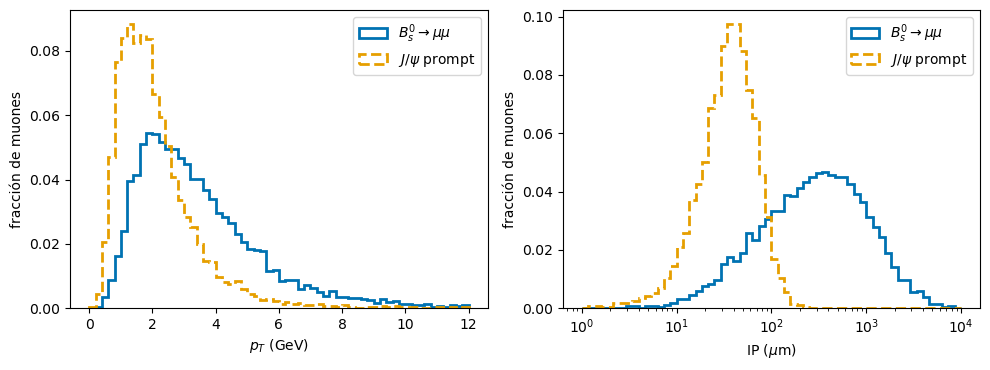

In [3]:
# (c) distribuciones por muón (los dos muones de cada suceso)
def muones(df, var):
    return np.r_[df[var + '1'], df[var + '2']]

fig, axs = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, var, bins, lab in [(axs[0], 'pt', np.linspace(0, 12, 61), r'$p_T$ (GeV)'),
                           (axs[1], 'ip', np.logspace(0, 4, 61), r'IP ($\mu$m)')]:
    for df, col, ls, lb in ((sig, C_SIG, '-', r'$B_s^0 \to \mu\mu$'), (bkg, C_BKG, '--', r'$J/\psi$ prompt')):
        v = muones(df, var)
        ax.hist(v, bins, weights=np.full(len(v), 1 / len(v)), histtype='step', lw=2, color=col, ls=ls, label=lb)
    ax.set_xlabel(lab); ax.set_ylabel('fracción de muones'); ax.legend()
axs[1].set_xscale('log')
plt.tight_layout()
for var in ('pt', 'ip'):
    print('mediana {:2s}:  señal {:6.1f}   fondo {:6.1f}'.format(var, np.median(muones(sig, var)),
                                                            np.median(muones(bkg, var))))

In [4]:
# (d) eficiencia por suceso: al menos un muón con pT > ptmin e IP > ipmin
def pasa(df, ptmin, ipmin):
    m1 = (df.pt1 > ptmin) & (df.ip1 > ipmin)
    m2 = (df.pt2 > ptmin) & (df.ip2 > ipmin)
    return m1 | m2, np.r_[m1, m2]

def eff(df, ptmin, ipmin):
    ev, mu = pasa(df, ptmin, ipmin)
    return ev.mean(), mu.mean()

def corte_minimo(budget, var, grid):
    # primer corte de la rejilla que deja la tasa por debajo del presupuesto
    for x in grid:
        cut = (x, 0) if var == 'pt' else (0, x)
        if R_bkg * eff(bkg, *cut)[0] <= budget:
            return cut

def mejor_corte(budget):
    best = None
    for pt in np.arange(0, 4.01, 0.25):
        for ip in np.arange(0, 300, 5):
            if R_bkg * eff(bkg, pt, ip)[0] <= budget:
                e = eff(sig, pt, ip)[0]
                if best is None or e > best[0]:
                    best = (e, pt, ip)
                break
    return best[1:]

for budget in (20, 10):
    print('--- {} Hz'.format(budget))
    cortes = {'solo pT ': corte_minimo(budget, 'pt', np.arange(0, 15, 0.1)),
              'solo IP ': corte_minimo(budget, 'ip', np.arange(0, 400, 1)),
              'pT e IP ': mejor_corte(budget)}
    for nombre, (pt, ip) in cortes.items():
        es, emu = eff(sig, pt, ip)
        nb = pasa(bkg, pt, ip)[0].sum()
        print('{}: pT > {:4.1f} GeV, IP > {:3.0f} um   R = {:4.1f} Hz   eff(Bs) = {:.2f}   '
              'eff/muón = {:.2f} -> 1-(1-e)^2 = {:.2f}   N_fondo = {} ({:.0%})'.format(
              nombre, pt, ip, R_bkg * eff(bkg, pt, ip)[0], es, emu, 1 - (1 - emu)**2, nb, 1 / np.sqrt(nb)))

--- 20 Hz


solo pT : pT >  6.8 GeV, IP >   0 um   R = 19.6 Hz   eff(Bs) = 0.15   eff/muón = 0.08 -> 1-(1-e)^2 = 0.15   N_fondo = 122 (9%)
solo IP : pT >  0.0 GeV, IP > 129 um   R = 19.5 Hz   eff(Bs) = 0.83   eff/muón = 0.72 -> 1-(1-e)^2 = 0.92   N_fondo = 121 (9%)
pT e IP : pT >  1.0 GeV, IP >  95 um   R = 19.3 Hz   eff(Bs) = 0.86   eff/muón = 0.76 -> 1-(1-e)^2 = 0.94   N_fondo = 120 (9%)
--- 10 Hz


solo pT : pT >  8.8 GeV, IP >   0 um   R = 10.0 Hz   eff(Bs) = 0.06   eff/muón = 0.03 -> 1-(1-e)^2 = 0.06   N_fondo = 62 (13%)
solo IP : pT >  0.0 GeV, IP > 144 um   R = 10.0 Hz   eff(Bs) = 0.82   eff/muón = 0.70 -> 1-(1-e)^2 = 0.91   N_fondo = 62 (13%)
pT e IP : pT >  1.0 GeV, IP > 105 um   R =  8.9 Hz   eff(Bs) = 0.84   eff/muón = 0.74 -> 1-(1-e)^2 = 0.93   N_fondo = 55 (13%)


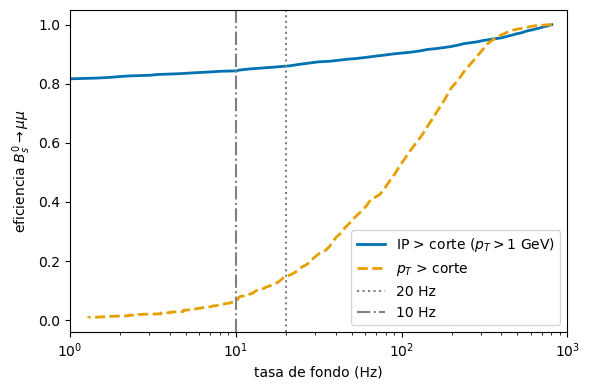

In [5]:
# (e) curva eficiencia de señal frente a tasa: corte en IP (pT > 1 GeV) y corte en pT
ips = np.arange(0, 400, 2)
pts = np.arange(0, 15, 0.1)
r_ip = [R_bkg * eff(bkg, 1.0, x)[0] for x in ips];  e_ip = [eff(sig, 1.0, x)[0] for x in ips]
r_pt = [R_bkg * eff(bkg, x, 0)[0] for x in pts];    e_pt = [eff(sig, x, 0)[0] for x in pts]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(r_ip, e_ip, color=C_SIG, ls='-',  lw=2, label=r'IP > corte ($p_T > 1$ GeV)')
ax.plot(r_pt, e_pt, color=C_BKG, ls='--', lw=2, label=r'$p_T$ > corte')
for b, ls in ((20, ':'), (10, '-.')):
    ax.axvline(b, color='gray', ls=ls, label='{} Hz'.format(b))
ax.set_xscale('log'); ax.set_xlim(1, 1e3)
ax.set_xlabel('tasa de fondo (Hz)'); ax.set_ylabel(r'eficiencia $B_s^0 \to \mu\mu$')
ax.legend(); plt.tight_layout()

In [6]:
# (f) sucesos B_s -> mu mu grabados en un año
pt, ip   = mejor_corte(20)
eff_trig = eff(sig, pt, ip)[0]
N = 2 * 144e-30 * 0.10 * 3.6e-9 * 0.50 * eff_trig * 5e39
print('eff_trig = {:.2f}   ->   N = {:.0f} sucesos/año'.format(eff_trig, N))

eff_trig = 0.86   ->   N = 222 sucesos/año


<details>
<summary><b>Solución</b></summary>

**(b)** $R = \sigma\,\mathcal{B}\,\varepsilon_{acc}\,\mathcal{L} \simeq 8\cdot10^{2}$ Hz, unas $40$ veces el
presupuesto: el trigger solo puede quedarse con un $2.5\,\%$ del fondo.

**(c)** El **IP** separa mucho mejor (medianas de $\sim 300$ frente a $\sim 36\ \mu$m). El $B_s^0$ vuela
$c\tau = 456\ \mu$m (por $\beta\gamma$) antes de desintegrarse, y el IP de sus muones es del orden de $c\tau$; el
$J/\psi$ prompt nace en el vértice primario, y su IP es solo la resolución, $\sigma_{IP} \simeq (15 + 29/p_T)\
\mu$m. El $p_T$ separa menos: los muones llevan $p^* \simeq m/2$ en el reposo de la madre ($2.7$ frente a $1.5$
GeV), pero los espectros de las madres son anchos y se solapan.

**(d)** Con $20$ Hz: solo $p_T > 6.8$ GeV deja un $15\,\%$ de la señal; solo IP $> 129\ \mu$m, un $83\,\%$;
$p_T > 1$ GeV e IP $> 95\ \mu$m, un $86\,\%$. El IP hace casi todo el trabajo; el corte suave en $p_T$ ayuda
porque la resolución en IP empeora a $p_T$ bajo. La eficiencia por muón es $0.76$, y con muones independientes
el «o» daría $1-(1-0.76)^2 = 0.94$, pero se mide $0.86$: los dos muones salen del mismo vértice, y si el $B_s^0$
se desintegra pronto los dos tienen IP pequeño a la vez. Están **correlacionados**.

**(e)** Con $10$ Hz se pierden solo dos puntos ($84\,\%$), porque la cola de IP del fondo cae muy deprisa; con
el corte en $p_T$ la eficiencia se hunde al $6\,\%$. La tasa se estima con unos $120$ sucesos de fondo que
pasan el corte ($55$ para $10$ Hz): una precisión del $9\,\%$ ($13\,\%$). Para fijar un trigger real hacen falta
muestras de fondo mucho mayores.

**(f)** $N = 2\,\sigma_{b\bar b}\,f_s\,\mathcal{B}\,\varepsilon_{acc}\,\varepsilon_{trig}\,\mathcal{L}_{int}
\simeq 2\cdot10^{2}$ sucesos al año, antes de la selección final: el trigger tiene que ser muy eficiente.

*Nota.* Las muestras son de juguete (espectros sencillos, desintegración isótropa y la resolución en IP de LHCb):
se generan con `tools/gen_trigger_bsmumu.py`. En un experimento real el fondo de un trigger de muones lo dominan
los $\pi$ y $K$ que se desintegran en vuelo y las desintegraciones semileptónicas de $c$ y $b$.

</details>

<div class="admonition tip">
<p class="admonition-title"><b>[>] Ejercicio 8 — Leer un perfil de verosimilitud: $B_s^0 \to \mu^+ + \mu^-$ en CMS</b></p>

Perfil de verosimilitud de CMS para $\mathcal{B}(B_s^0 \to \mu^+ + \mu^-)$ con $140$ fb$^{-1}$ a $13$ TeV, y
regiones permitidas en el plano $\mathcal{B}(B_s^0 \to \mu^+ + \mu^-)$–$\mathcal{B}(B^0 \to \mu^+ + \mu^-)$. El
modelo estándar predice $\mathcal{B}_{SM}(B_s^0 \to \mu^+ + \mu^-) = (3.66 \pm 0.14)\cdot10^{-9}$.

(a) Valor central. (b) Lee la curva en $\mathcal{B} = 2, 3, 5, 6\cdot10^{-9}$ y estima el error por cada lado
suponiendo $-2\Delta\ln L \simeq (\mathcal{B}-\hat{\mathcal{B}})^2/\sigma^2$. (c) Significancia de la observación.
(d) ¿Cuánto valdría la curva en $\mathcal{B} = 0$ si fuera una parábola? (e) Compatibilidad con el modelo
estándar. (f) Figura bidimensional: ¿se ha observado $B^0 \to \mu^+ + \mu^-$? ¿Por qué el contorno de $1\sigma$ es
más ancho que el intervalo de $1\sigma$ de arriba?

| | |
| :-: | :-: |
| <img src="../imgs/bol3_bsmumu_cms_nll1d.png" width=380> | <img src="../imgs/bol3_bsmumu_cms_nll2d.png" width=380> |

CMS, [Phys. Lett. B 842 (2023) 137955](https://arxiv.org/abs/2212.10311) (CC BY 4.0).

</div>

mínimo en B = 3.85e-9;  -2DlnL = 1 en [3.44, 4.26]  ->  -0.41 +0.40
B = 0e-9:  -2DlnL = 157.0   sigma = 0.31
B = 2e-9:  -2DlnL =  27.7   sigma = 0.35
B = 3e-9:  -2DlnL =   4.8   sigma = 0.39
B = 5e-9:  -2DlnL =   6.9   sigma = 0.44
B = 6e-9:  -2DlnL =  21.0   sigma = 0.47
B = 8e-9:  -2DlnL =  62.1   sigma = 0.53
Z(B = 0) = 12.5 sigma,  Z(SM) = 0.4 sigma


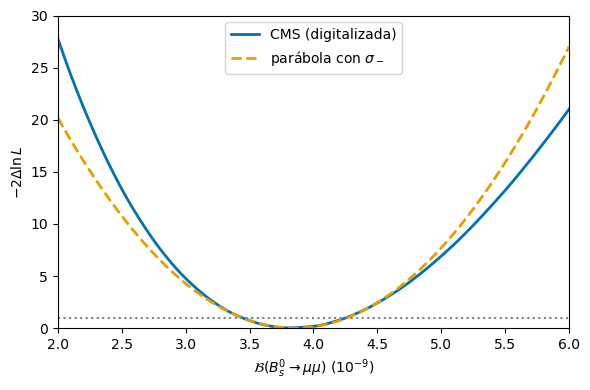

In [7]:
# Curva digitalizada del PDF vectorial de la figura (puntos del trazo publicado)
cms = pd.read_csv(DATOS + 'bsmumu_cms_nll1d_digitalizado.csv', comment='#')
f = PchipInterpolator(cms.br, cms.m2dlnl)
x = np.linspace(0, 8, 8001); y = f(x)
# el trazo está muestreado cada ~0.2: el mínimo se toma de una parábola a los puntos con -2DlnL < 3
near = cms.m2dlnl < 3
a2, a1, a0 = np.polyfit(cms.br[near], cms.m2dlnl[near], 2)
bh = -a1 / (2 * a2); i = np.searchsorted(x, bh)
lo = x[:i][np.argmin(abs(y[:i] - 1))]; hi = x[i:][np.argmin(abs(y[i:] - 1))]
print('mínimo en B = {:.2f}e-9;  -2DlnL = 1 en [{:.2f}, {:.2f}]  ->  -{:.2f} +{:.2f}'.format(bh, lo, hi, bh - lo, hi - bh))
for b in (0, 2, 3, 5, 6, 8):
    print('B = {}e-9:  -2DlnL = {:5.1f}   sigma = {:.2f}'.format(b, f(b), abs(b - bh) / np.sqrt(f(b))))
print('Z(B = 0) = {:.1f} sigma,  Z(SM) = {:.1f} sigma'.format(np.sqrt(f(0)), np.sqrt(f(3.66))))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, y, color=C_SIG, lw=2, label='CMS (digitalizada)')
sm = (bh - lo)
ax.plot(x, (x - bh)**2 / sm**2, color=C_BKG, ls='--', lw=2, label=r'parábola con $\sigma_-$')
ax.axhline(1, color='gray', ls=':')
ax.set_ylim(0, 30); ax.set_xlim(2, 6)
ax.set_xlabel(r'$\mathcal{B}(B_s^0 \to \mu\mu)\ (10^{-9})$'); ax.set_ylabel(r'$-2\Delta\ln L$')
ax.legend(); plt.tight_layout()

<details>
<summary><b>Solución</b></summary>

**(a)** El mínimo está en $\hat{\mathcal{B}} \simeq 3.9\cdot10^{-9}$ (el artículo da $4.02$; la curva es muy plana
cerca del mínimo y leerlo a mejor que $\pm 0.2$ es difícil).

**(b)** Se lee $-2\Delta\ln L \simeq 28, 5, 7, 21$, y $\sigma \simeq 0.35, 0.39, 0.44, 0.47\cdot10^{-9}$:
$\mathcal{B} \simeq (3.9^{+0.45}_{-0.4})\cdot10^{-9}$, la curva es más abierta hacia arriba y la asimetría crece al alejarse del mínimo (en $-2\Delta\ln L = 1$ es casi simétrico, $\pm 0.4$), como corresponde a una
medida de conteo (Poisson). El artículo da, en total, $^{+0.52}_{-0.47}$.

**(c)** $-2\Delta\ln L(0) \simeq 157$: $Z \simeq \sqrt{157} \simeq 12.5\sigma$. Observación sin duda.

**(d)** Una parábola con $\sigma_- \simeq 0.37$ daría $(3.9/0.37)^2 \simeq 110$, no $157$: lejos del mínimo la
verosimilitud no es gaussiana. Los errores se leen en $-2\Delta\ln L = 1$; no se extrapolan.

**(e)** En $\mathcal{B}_{SM}$ la curva vale $\simeq 0.2$: $Z \simeq 0.5\sigma$, plenamente compatible.

**(f)** $\mathcal{B}(B^0 \to \mu^+ + \mu^-) = 0$ está dentro de $1\sigma$: no hay evidencia (CMS da
$< 1.5\cdot10^{-10}$ al $90\,\%$ CL). El modelo estándar está dentro de $1\sigma$. El contorno de $1\sigma$ en 2D
encierra el $68.3\,\%$ para **los dos** parámetros a la vez, que para dos gaussianas es $-2\Delta\ln L = 2.30$:
su proyección ($\simeq 3.3$–$4.5$) es más ancha que el intervalo de un solo parámetro ($\simeq 3.5$–$4.3$).

</details>

<div class="admonition tip">
<p class="admonition-title"><b>[>] Ejercicio 10 — Leer una <i>posterior</i>: la masa del neutrino en KATRIN</b></p>

En su segunda campaña KATRIN obtuvo, con un ajuste frecuentista, $m_\nu^2 = (0.26 \pm 0.34)$ eV$^2$ y
$m_\nu < 0.9$ eV al $90\,\%$ CL. La figura es la *posterior* de $m_\nu^2$ de los mismos datos con una *prior*
plana en $m_\nu^2 \ge 0$, en intervalos de $0.01$ eV$^2$.

(a) ¿Qué representa la posterior? ¿Por qué empieza en $m_\nu^2 = 0$ con un valor distinto de cero?
(b) ¿Dónde está el máximo? (c) Estima $P(m_\nu^2 < 0.25$ eV$^2)$. (d) Límite en $m_\nu$ al $90\,\%$ de
credibilidad; compáralo con el frecuentista. (e) Reprodúcelo con una verosimilitud gaussiana $(0.26, 0.34)$ y la
prior plana. (f) Repite con una prior plana en $m_\nu$. (g) ¿Y si el ajuste hubiera dado $m_\nu^2 = -0.5 \pm 0.34$
eV$^2$?

<img src="../imgs/bol3_katrin_knm2_posterior.png" width=420>

KATRIN, [Nature Phys. 18 (2022) 160](https://arxiv.org/abs/2105.08533) (CC BY 4.0).

</div>

m2_fit =  0.26, prior plana en m2:  m2 < 0.74 eV^2,  m < 0.86 eV


m2_fit =  0.26, prior plana en m :  m2 < 0.61 eV^2,  m < 0.78 eV
m2_fit = -0.50, prior plana en m2:  m2 < 0.33 eV^2,  m < 0.58 eV
P(m2 < 0.25) = 0.35


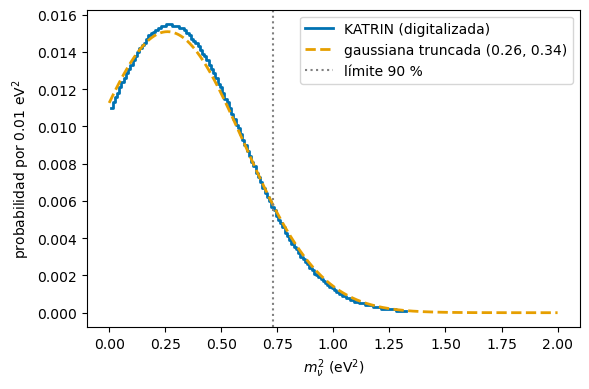

In [8]:
# (e)-(g) posterior = verosimilitud gaussiana en m^2 x prior, normalizada; límite al 90 %
def limite90(mu, s, prior='m2'):
    if prior == 'm2':
        post = lambda t: stats.norm.pdf(t, mu, s)                 # prior plana en m^2 >= 0
    else:
        post = lambda t: stats.norm.pdf(t, mu, s) / np.sqrt(t)    # prior plana en m: pi(m^2) ~ 1/m
    Z = integrate.quad(post, 0, 10, points=[1e-9])[0]
    q = optimize.brentq(lambda u: integrate.quad(post, 0, u, points=[1e-9])[0] / Z - 0.9, 1e-6, 5)
    return q, np.sqrt(q)

for mu, prior in ((0.26, 'm2'), (0.26, 'm'), (-0.5, 'm2')):
    q, m = limite90(mu, 0.34, prior)
    print('m2_fit = {:5.2f}, prior plana en {:2s}:  m2 < {:.2f} eV^2,  m < {:.2f} eV'.format(mu, prior, q, m))

# comparación con la posterior publicada (digitalizada)
kat = pd.read_csv(DATOS + 'katrin_knm2_posterior_digitalizado.csv', comment='#')
c = 0.5 * (kat.m2_lo + kat.m2_hi)
t = np.linspace(0, 2, 401)
g = stats.norm.pdf(t, 0.26, 0.34) / (1 - stats.norm.cdf(0, 0.26, 0.34)) * 0.01   # prob. por intervalo de 0.01
fig, ax = plt.subplots(figsize=(6, 4))
ax.step(c, kat.prob, where='mid', color=C_SIG, lw=2, label='KATRIN (digitalizada)')
ax.plot(t, g, color=C_BKG, ls='--', lw=2, label='gaussiana truncada (0.26, 0.34)')
ax.axvline(0.73, color='gray', ls=':', label=r'límite 90 %')
ax.set_xlabel(r'$m_\nu^2$ (eV$^2$)'); ax.set_ylabel('probabilidad por 0.01 eV$^2$')
ax.legend(); plt.tight_layout()
print('P(m2 < 0.25) = {:.2f}'.format(kat.prob[c < 0.25].sum() / kat.prob.sum()))

<details>
<summary><b>Solución</b></summary>

**(a)** $p(m_\nu^2\,|\,\text{datos}) \propto L(\text{datos}\,|\,m_\nu^2)\,\pi(m_\nu^2)$: la verosimilitud por la
prior, normalizada. La prior es nula para $m_\nu^2 < 0$, así que la posterior es la verosimilitud **cortada** en
cero; como el mejor ajuste está a menos de $1\sigma$ de cero, en $m_\nu^2 = 0$ la posterior no es pequeña.

**(b)** En $m_\nu^2 \simeq 0.26$ eV$^2$: con prior plana, posterior y verosimilitud tienen el mismo máximo.

**(c)** $25$ intervalos de altura media $\simeq 0.0135$: $P \simeq 0.34$.

**(d)** $m_\nu^2 < 0.73$ eV$^2$, $m_\nu < 0.85$ eV al $90\,\%$ de credibilidad: con esta prior y estos datos, la
probabilidad de que $m_\nu < 0.85$ eV es del $90\,\%$. El límite frecuentista ($0.9$ eV) habla del procedimiento:
el intervalo así construido contiene el valor verdadero en el $90\,\%$ de los experimentos.

**(e)** La gaussiana truncada da $0.74$ eV$^2$ ($0.86$ eV), muy cerca de KATRIN: la verosimilitud es casi
gaussiana porque domina la estadística.

**(f)** Prior plana en $m_\nu$, $\pi(m_\nu^2) \propto 1/m_\nu$: más peso a valores pequeños, $m_\nu^2 < 0.61$
eV$^2$, $m_\nu < 0.78$ eV. Si los datos no determinan el parámetro, el resultado bayesiano depende de la prior.

**(g)** $m_\nu^2 < 0.33$ eV$^2$, $m_\nu < 0.58$ eV: mejor que la sensibilidad ($0.7$ eV) solo por una fluctuación
hacia abajo. Por eso KATRIN usa como resultado principal el método de Lokhov–Tkachov, que no da límites mejores que
la sensibilidad cuando el ajuste es negativo.

</details>